
# 08. 이어진 단서: 사다리 3단계 "생각하기" 졸업 시험

**문제**: 문장 순서를 섞어서 준다. 단서를 여러 번 이어야 풀린다.
> "빨간 문은 해 열쇠야." / "파란 문은 빨간 문과 같은 열쇠를 써." / "초록 문이랑 파란 문은 열쇠가 같아." → **초록 문은?** (고리 3개)

- **학습은 고리 1~3개까지만** 했다. **시험은 1~6개**다. 4~6개는 처음 보는 길이다.
- 20%는 고리가 끊겨 있어서 "모름"이 정답이다.

**시스템**
- 읽기 부품 본체는 얼렸다.
- 새로 배운 것: 연결 머리, 생각 루프(문마다 상태, 한 번 생각할 때 한 칸씩 전달), 답 머리.
- 학습 순서: ① 연결과 전달 (처음엔 모든 연결을 켜고 가지치기) → ② 연결을 얼리고 모든 문의 답 채점.
- 멈춤은 고정 규칙이다. 모든 문의 답이 2번 연속 거의 안 바뀌면 멈춘다(사람이 준 틀).

**평가**: 한 번도 안 본 seed 45–47. 개발 과정에서 고친 것은 별도 개발 세트로만 결정했다.


In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V

V.setup()
SEEDS = (45, 46, 47)
LENGTHS = range(1, 7)
runs = {s: json.loads((S.RESULTS / f"world-v3_thinker-grown_seed-{s}.json").read_text(encoding="utf-8")) for s in SEEDS}
def by(s, key, l, part="test"):
    return runs[s][part]["by_length"][str(l)][key]

long_scores = [np.mean([by(s, "adaptive", l) for l in (4, 5, 6)]) for s in SEEDS]
forced3 = [np.mean([by(s, "forced", l)[2] for l in (4, 5, 6)]) for s in SEEDS]
print("L=4-6 스스로 멈춤:", [round(x, 3) for x in long_scores], "평균", round(np.mean(long_scores), 3))
print("L=4-6 3번째에서 억지로 멈춤:", [round(x, 3) for x in forced3])
print("L=1-3:", [round(np.mean([by(s, "adaptive", l) for l in (1, 2, 3)]), 3) for s in SEEDS])
print("도착 전 정답 확률 (L>=2):", [max(by(s, "pre_arrival_p_true", l) for l in range(2, 7)) for s in SEEDS])


L=4-6 스스로 멈춤: [np.float64(0.95), np.float64(1.0), np.float64(1.0)] 평균 0.983
L=4-6 3번째에서 억지로 멈춤: [np.float64(0.197), np.float64(0.213), np.float64(0.193)]
L=1-3: [np.float64(1.0), np.float64(1.0), np.float64(1.0)]
도착 전 정답 확률 (L>=2): [0.3376, 0.3334, 0.3333]



## 1. 처음 보는 긴 고리도 푼다


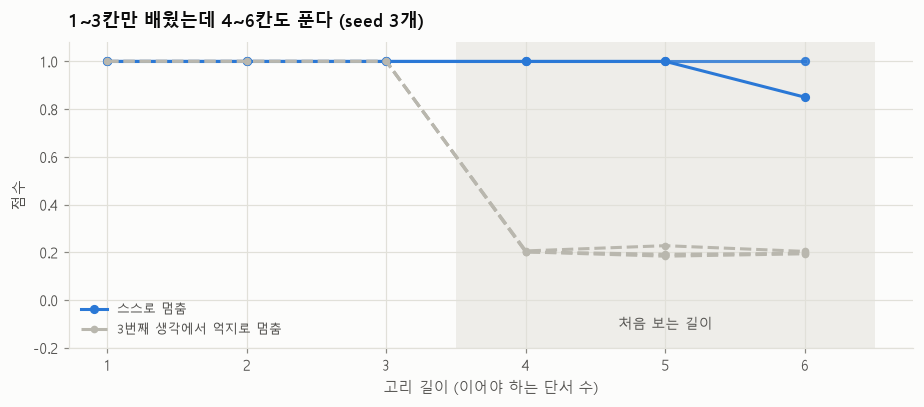

In [2]:

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.axvspan(3.5, 6.5, color=V.GRID, alpha=0.5, lw=0)
ax.text(5, -0.12, "처음 보는 길이", ha="center", fontsize=9, color=V.TEXT_SECONDARY)
for i, s in enumerate(SEEDS):
    ax.plot(LENGTHS, [by(s, "adaptive", l) for l in LENGTHS], "-o", color=V.BLUE, alpha=[1, 0.7, 0.45][i], ms=5,
            label="스스로 멈춤" if i == 0 else None)
    ax.plot(LENGTHS, [by(s, "forced", l)[2] for l in LENGTHS], "--o", color=V.NEUTRAL, ms=4,
            label="3번째 생각에서 억지로 멈춤" if i == 0 else None)
ax.set_xticks(list(LENGTHS))
ax.set_xlabel("고리 길이 (이어야 하는 단서 수)")
ax.set_ylabel("점수")
ax.set_ylim(-0.2, 1.08)
ax.legend(loc="lower left", fontsize=8.5, frameon=False)
ax.set_title("1~3칸만 배웠는데 4~6칸도 푼다 (seed 3개)", pad=10)
fig.tight_layout()
plt.show()



## 2. 어려울수록 오래 생각한다

답이 있는 문제의 평균 생각 횟수다. 점선은 "정보가 도착하는 데 필요한 최소 횟수(= 고리 길이)"다. 멈춤 규칙은 도착한 뒤 "2번 연속 안 바뀌나" 확인하고 멈추므로 그보다 조금 더 생각한다.


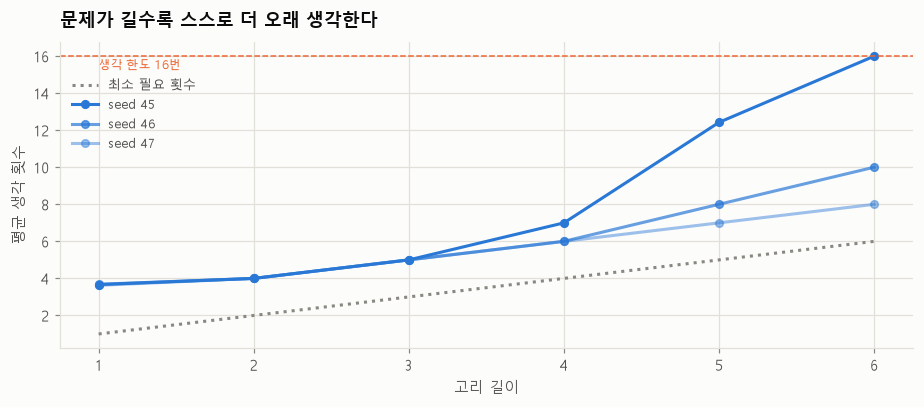

In [3]:

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(LENGTHS, list(LENGTHS), ":", color=V.MUTED, label="최소 필요 횟수")
for i, s in enumerate(SEEDS):
    steps = [by(s, "mean_steps_answerable", l) for l in LENGTHS]
    ax.plot(LENGTHS, steps, "-o", color=V.BLUE, alpha=[1, 0.7, 0.45][i], ms=5, label=f"seed {s}")
ax.axhline(16, color=V.ORANGE, lw=1, linestyle="--")
ax.text(1, 15.3, "생각 한도 16번", fontsize=8, color=V.ORANGE)
ax.set_xticks(list(LENGTHS))
ax.set_xlabel("고리 길이")
ax.set_ylabel("평균 생각 횟수")
ax.legend(fontsize=8.5, frameon=False, loc="upper left", bbox_to_anchor=(0, 0.92))
ax.set_title("문제가 길수록 스스로 더 오래 생각한다", pad=10)
fig.tight_layout()
plt.show()



## 3. 정보는 연결을 따라서만 움직인다 (지름길 없음)

6칸 고리에서 억지로 t번 생각시키고 멈췄을 때의 점수다.
- 정보가 도착하기 전 정답 확률은 0.333으로, 찍기와 같았다(모든 seed, 모든 길이). 지름길을 쓰지 않는다는 뜻이다.
- seed 47은 6번째, seed 46은 7–8번째 생각에 도착한다. seed 45는 학습 길이(3칸)를 넘어서면 전달이 느려져서 13번째 이후에야 도착했다. 그래서 한도 16번 안에 0.85까지만 왔다.


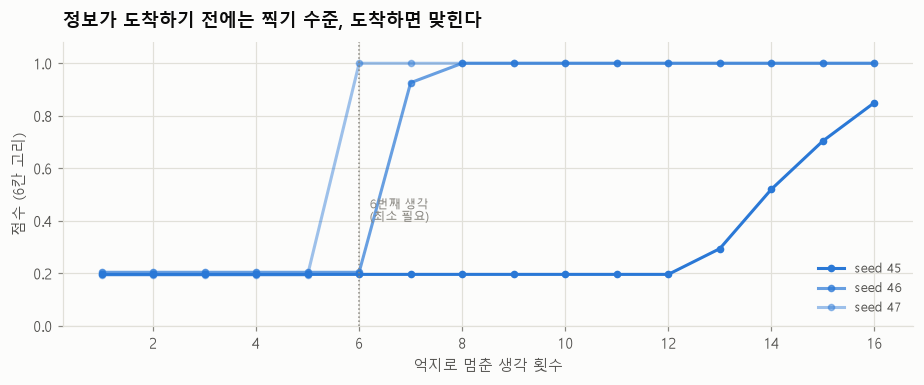

In [4]:

fig, ax = plt.subplots(figsize=(8.5, 3.6))
for i, s in enumerate(SEEDS):
    f = by(s, "forced", 6)
    ax.plot(range(1, len(f) + 1), f, "-o", color=V.BLUE, alpha=[1, 0.7, 0.45][i], ms=4, label=f"seed {s}")
ax.axvline(6, color=V.MUTED, linestyle=":", lw=1)
ax.text(6.2, 0.4, "6번째 생각\n(최소 필요)", fontsize=8, color=V.MUTED)
ax.set_xlabel("억지로 멈춘 생각 횟수")
ax.set_ylabel("점수 (6칸 고리)")
ax.set_ylim(0, 1.08)
ax.legend(fontsize=8.5, frameon=False, loc="lower right")
ax.set_title("정보가 도착하기 전에는 찍기 수준, 도착하면 맞힌다", pad=10)
fig.tight_layout()
plt.show()



## 4. 정리

- **3단계 졸업.** 미리 정한 기준 (a)–(e)를 모두 통과했다.
  - 처음 보는 4–6칸 평균 0.983 (seed별 0.950 / 1.000 / 1.000)
  - 3번째에서 억지로 멈춤(약 0.20)보다 +0.75 이상
  - 생각 횟수가 길이에 따라 증가
  - 1–3칸 1.000
  - 도착 전 정답 확률 0.333
- seed 45의 6칸은 0.85다. 전달이 느려서 생각 한도 16번 안에 다 도착하지 못했다(16번 억지로 생각시켜도 0.85).
- 학습된 멈춤 머리(비교용)는 seed 47에서는 6칸까지 1.0, seed 46은 0.86, seed 45는 0.24였다. **언제 멈출지를 학습으로 일반화하는 것은 아직 불안정**하고, 그래서 고정 규칙을 썼다.
- **과정에서 배운 것** (개발 세트로만 결정):
  - 세계의 지름길 2개를 고쳤다(가장 많이 나온 열쇠, 연결 있는 사실 문).
  - 연결은 "합"이 아니라 "한 문장이 말하나(최대)"로 정하고, 0/1로 둔다.
  - 처음엔 모든 연결을 켜고 가지치기한다.
  - 순서대로 키운다(연결 → 얼리고 전체 학습).
